In [9]:
import sqlite3
from contextlib import closing
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [149]:
with closing(sqlite3.connect("../db.sqlite3")) as connection:
    table1 = pd.read_sql_query("SELECT * FROM restaurant_order;", connection)
    table2 = pd.read_sql_query("SELECT * FROM restaurant_orderitem;", connection)
    table3 = pd.read_sql_query("SELECT * FROM restaurant_product;", connection)
    
    result1 = table2.merge(table1, left_on='order_id', right_on='id', how='inner')
    result = result1.merge(table3, left_on='product_id', right_on='id', how='inner')
    result.to_csv('restaurant_data.csv', index=False)

    

In [123]:
df = pd.read_csv('restaurant_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.drop(axis=1, labels=['id_x', 'id_y', 'order_id', 'product_id', 'id'], inplace=True)
df.head()

,quantity,datetime,price,name
0,2,2019-08-03 20:25:00,0.80,Plain Papadum
1,1,2019-08-03 20:25:00,12.95,King Prawn Balti
2,1,2019-08-03 20:25:00,2.95,Garlic Naan
3,1,2019-08-03 20:25:00,3.95,Mushroom Rice
4,1,2019-08-03 20:25:00,8.95,Paneer Tikka Masala


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

In [124]:
top_10_products = df['quantity'].groupby(df['name']).sum().sort_values(ascending=False)[:10]
top_10_products.head(10)

name
Plain Papadum           10648
Pilau Rice               6367
Plain Naan               4983
Garlic Naan              3318
Plain Rice               2964
Onion Bhajee             2749
Mango Chutney            2504
Chicken Tikka Masala     2473
Chapati                  1935
Mint Sauce               1840
Name: quantity, dtype: int64

In [125]:
def func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

<Axes: title={'center': 'Top 10 products'}, ylabel='quantity'>

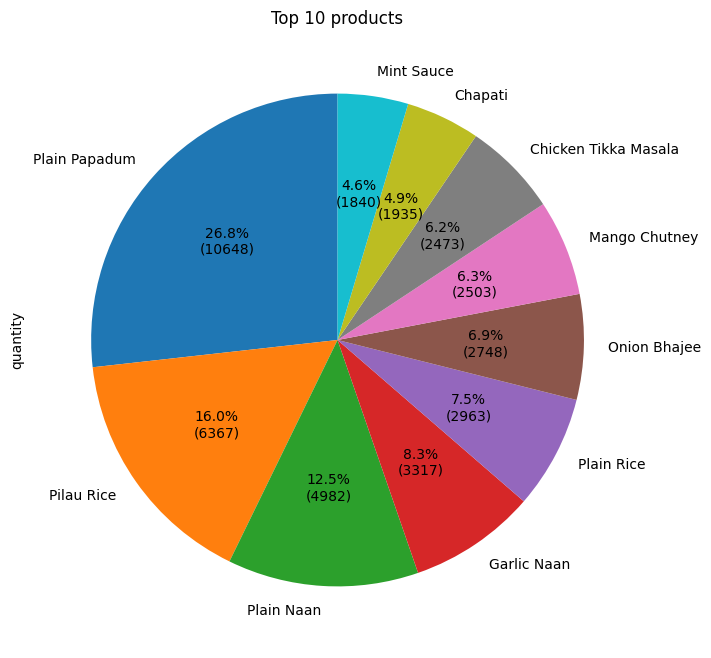

In [126]:
top_10_products.plot.pie(figsize=(10,8), autopct=lambda pct: func(pct, top_10_products), title="Top 10 products", startangle=90)

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

In [127]:
df['item_prices'] = df["quantity"] * df["price"]
df.head()


,quantity,datetime,price,name,item_prices
0,2,2019-08-03 20:25:00,0.80,Plain Papadum,1.60
1,1,2019-08-03 20:25:00,12.95,King Prawn Balti,12.95
2,1,2019-08-03 20:25:00,2.95,Garlic Naan,2.95
3,1,2019-08-03 20:25:00,3.95,Mushroom Rice,3.95
4,1,2019-08-03 20:25:00,8.95,Paneer Tikka Masala,8.95


In [128]:
top_10_bestsellers = df["item_prices"].groupby(df["name"]).sum().sort_values(ascending=False)[:10]
top_10_bestsellers.head(10)

name
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: item_prices, dtype: float64

<Axes: title={'center': 'Top 10 bestsellers'}, ylabel='item_prices'>

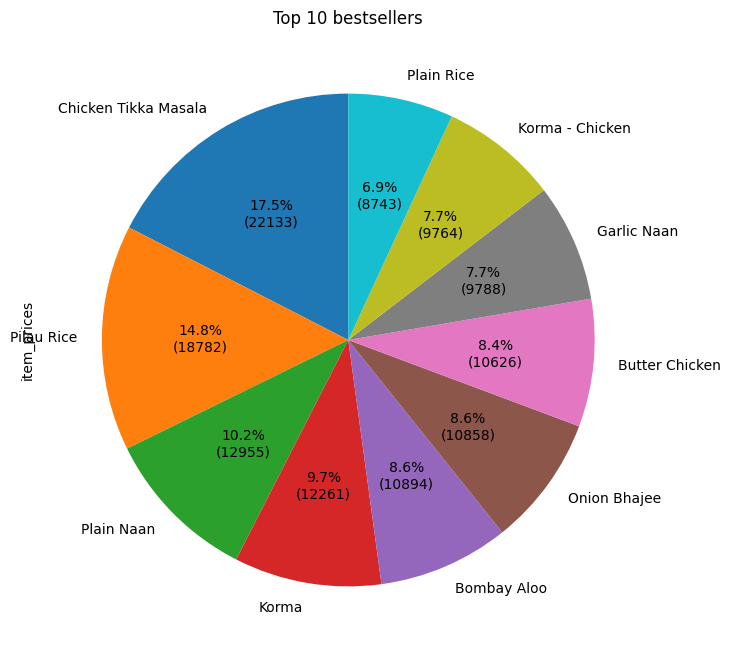

In [129]:
top_10_bestsellers.plot.pie(figsize=(10,8), autopct=lambda pct: func(pct, top_10_bestsellers), title="Top 10 bestsellers", startangle=90)

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

In [130]:
df["order_hour"] = df["datetime"].dt.hour
df.head()

,quantity,datetime,price,name,item_prices,order_hour
0,2,2019-08-03 20:25:00,0.80,Plain Papadum,1.60,20
1,1,2019-08-03 20:25:00,12.95,King Prawn Balti,12.95,20
2,1,2019-08-03 20:25:00,2.95,Garlic Naan,2.95,20
3,1,2019-08-03 20:25:00,3.95,Mushroom Rice,3.95,20
4,1,2019-08-03 20:25:00,8.95,Paneer Tikka Masala,8.95,20


In [132]:
revenue_by_hour = df["item_prices"].groupby(df["order_hour"]).sum()
revenue_by_hour.head()

order_hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: item_prices, dtype: float64

<Axes: title={'center': 'Revenue by order hour'}, xlabel='Order hour', ylabel='Revenue'>

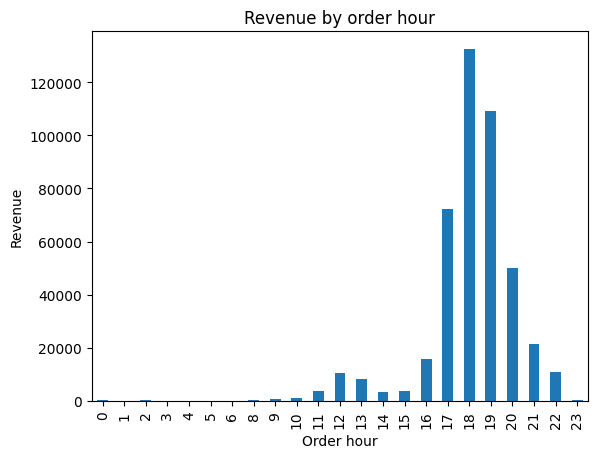

In [141]:
revenue_by_hour.plot.bar(title="Revenue by order hour", xlabel="Order hour", ylabel="Revenue")

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

In [145]:
df["order_day"] = df["datetime"].dt.weekday
df.head()

,quantity,datetime,price,name,item_prices,order_hour,order_day
0,2,2019-08-03 20:25:00,0.80,Plain Papadum,1.60,20,5
1,1,2019-08-03 20:25:00,12.95,King Prawn Balti,12.95,20,5
2,1,2019-08-03 20:25:00,2.95,Garlic Naan,2.95,20,5
3,1,2019-08-03 20:25:00,3.95,Mushroom Rice,3.95,20,5
4,1,2019-08-03 20:25:00,8.95,Paneer Tikka Masala,8.95,20,5


In [146]:
revenue_by_day = df["item_prices"].groupby(df["order_day"]).sum()
revenue_by_day.head()

order_day
0     40008.30
1     38145.65
2     41246.20
3     46021.55
4    100339.15
Name: item_prices, dtype: float64

<Axes: title={'center': 'Revenue by day of the week'}, xlabel='Order weekday', ylabel='Revenue'>

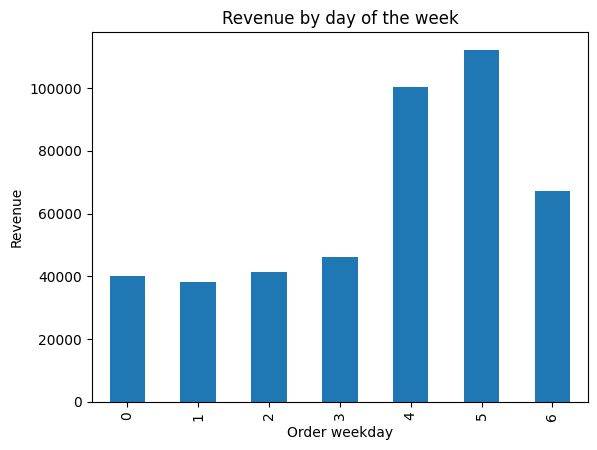

In [148]:
revenue_by_day.plot.bar(title="Revenue by day of the week", xlabel="Order weekday", ylabel="Revenue")